In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
print("=" * 70)
print("MODEL 4 — KMEANS MANDI CLUSTERING")
print("=" * 70)


MODEL 4 — KMEANS MANDI CLUSTERING


In [3]:
df = pd.read_csv(
    "../data/raw/final_dataset.csv"
)

print("\nDataset shape:", df.shape)



Dataset shape: (54340, 28)


In [4]:
# STEP 2 — DATA TYPES
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

numeric_columns = [
    "Modal_Price",
    "Arrival",
    "Max_Temp",
    "Min_Temp",
    "Rainfall_mm",
    "WindSpeed"
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


In [5]:
# STEP 3 — CHECK DISTRICT / MANDI
print("\n" + "=" * 70)
print("DISTRICT / MANDI CHECK")
print("=" * 70)

print(
    "District column exists:",
    "District" in df.columns
)

print(
    "\nNumber of districts:",
    df["District"].nunique()
)

print("\nDistricts:")

print(
    df["District"]
    .dropna()
    .unique()
)



DISTRICT / MANDI CHECK
District column exists: True

Number of districts: 10

Districts:
<ArrowStringArray>
[               'Ahmednagar',                      'Pune',
                    'Nashik',                   'Solapur',
                    'Nagpur',                  'Kolhapur',
                    'Sangli',                    'Satara',
                   'Jalgaon', 'Chhatrapati Sambhajinagar']
Length: 10, dtype: str


In [7]:
# STEP 4 — CREATE DISTRICT-LEVEL FEATURES
print("\n" + "=" * 70)
print("CREATING DISTRICT-LEVEL FEATURES")
print("=" * 70)


district_features = (
    df.groupby("District")
    .agg(
        Average_Price=(
            "Modal_Price",
            "mean"
        ),

        Price_Volatility=(
            "Modal_Price",
            "std"
        ),

        Average_Arrival=(
            "Arrival",
            "mean"
        ),

        Average_Max_Temp=(
            "Max_Temp",
            "mean"
        ),
 Average_Min_Temp=(
            "Min_Temp",
            "mean"
        ),

        Average_Rainfall=(
            "Rainfall_mm",
            "mean"
        ),

        Average_WindSpeed=(
            "WindSpeed",
            "mean"
        )
    )
    .reset_index()
)



CREATING DISTRICT-LEVEL FEATURES


In [8]:
# STEP 5 — CHECK FEATURES
print("\nDistrict-level dataset shape:")

print(
    district_features.shape
)


print("\nDistrict-level features:")

print(
    district_features
)


# ==============================================================
# STEP 6 — HANDLE MISSING VALUES
# ==============================================================

cluster_features = [
    "Average_Price",
    "Price_Volatility",
    "Average_Arrival",
    "Average_Max_Temp",
    "Average_Min_Temp",
    "Average_Rainfall",
    "Average_WindSpeed"
]


print("\n" + "=" * 70)
print("MISSING VALUE CHECK")

print("=" * 70)

print(
    district_features[
        cluster_features
    ]
    .isnull()
    .sum()
)


district_features = district_features.dropna(
    subset=cluster_features
)


print(
    "\nRows after removing missing values:",
    len(district_features)
)




District-level dataset shape:
(10, 8)

District-level features:
                    District  Average_Price  Price_Volatility  \
0                 Ahmednagar    2552.735193       1352.669823   
1  Chhatrapati Sambhajinagar    2552.735193       1352.669823   
2                    Jalgaon    2552.735193       1352.669823   
3                   Kolhapur    2552.735193       1352.669823   
4                     Nagpur    2552.735193       1352.669823   
5                     Nashik    2552.735193       1352.669823   
6                       Pune    2552.735193       1352.669823   
7                     Sangli    2552.735193       1352.669823   
8                     Satara    2552.735193       1352.669823   
9                    Solapur    2552.735193       1352.669823   

   Average_Arrival  Average_Max_Temp  Average_Min_Temp  Average_Rainfall  \
0      5378.557335         30.749926         20.085554          2.783051   
1      5378.557335         30.896117         20.800718          2.8

In [9]:
# STEP 7 — SCALE FEATURES
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    district_features[
        cluster_features
    ]
)


print("\nScaled feature shape:")

print(
    X_scaled.shape
)


print("\n" + "=" * 70)
print("MODEL 4 STEP 1 COMPLETED")
print("=" * 70)


Scaled feature shape:
(10, 7)

MODEL 4 STEP 1 COMPLETED



STEP 2 — FINDING OPTIMAL NUMBER OF CLUSTERS

Testing K = 2
Inertia: 15.824
Silhouette Score: 0.5055

Testing K = 3
Inertia: 9.795
Silhouette Score: 0.475

Testing K = 4
Inertia: 6.615
Silhouette Score: 0.2791

Testing K = 5
Inertia: 4.157
Silhouette Score: 0.2364

Testing K = 6
Inertia: 2.817
Silhouette Score: 0.1492

CLUSTER EVALUATION RESULTS
   K    Inertia  Silhouette_Score
0  2  15.824369          0.505458
1  3   9.795111          0.475032
2  4   6.615070          0.279088
3  5   4.156689          0.236379
4  6   2.816822          0.149249

BEST NUMBER OF CLUSTERS
Best K: 2
Best Silhouette Score: 0.5055


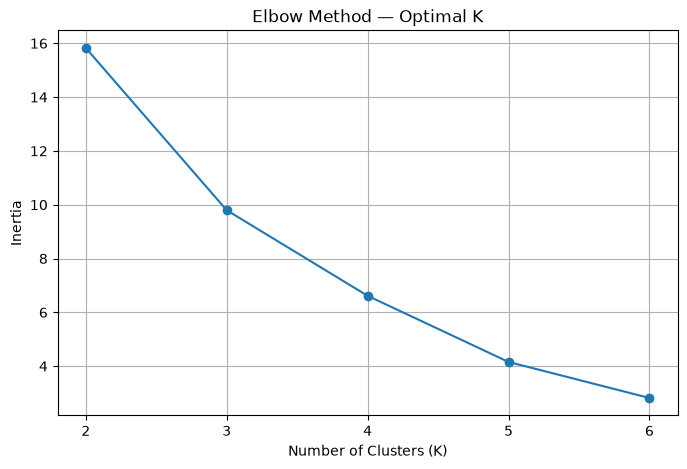

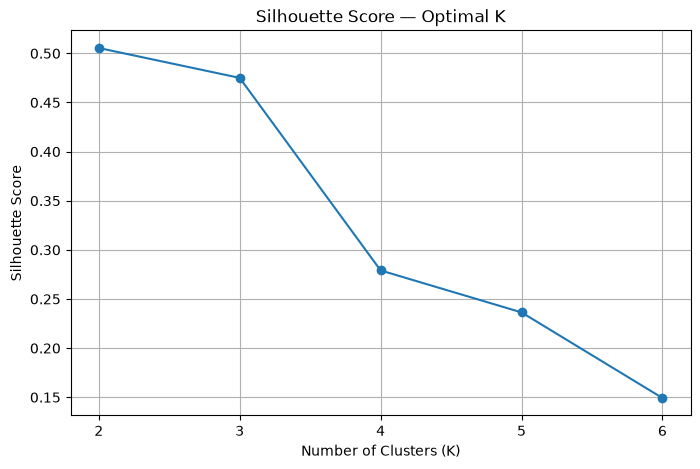


MODEL 4 — STEP 2 COMPLETED


In [10]:
# ==============================================================
# STEP 2 — FIND OPTIMAL NUMBER OF CLUSTERS
# ==============================================================

import matplotlib.pyplot as plt


print("\n" + "=" * 70)
print("STEP 2 — FINDING OPTIMAL NUMBER OF CLUSTERS")
print("=" * 70)


# --------------------------------------------------------------
# Test different K values
# --------------------------------------------------------------

k_values = range(2, 7)

inertia_values = []
silhouette_values = []


for k in k_values:

    print("\nTesting K =", k)

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        X_scaled
    )

    # Elbow value
    inertia = kmeans.inertia_

    # Silhouette score
    silhouette = silhouette_score(
        X_scaled,
        cluster_labels
    )

    inertia_values.append(inertia)
    silhouette_values.append(silhouette)

    print("Inertia:", round(inertia, 3))
    print("Silhouette Score:", round(silhouette, 4))


# ==============================================================
# DISPLAY RESULTS
# ==============================================================

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia_values,
    "Silhouette_Score": silhouette_values
})


print("\n" + "=" * 70)
print("CLUSTER EVALUATION RESULTS")
print("=" * 70)

print(results)


# ==============================================================
# BEST K USING SILHOUETTE SCORE
# ==============================================================

best_k = results.loc[
    results["Silhouette_Score"].idxmax(),
    "K"
]


print("\n" + "=" * 70)
print("BEST NUMBER OF CLUSTERS")
print("=" * 70)

print(
    "Best K:",
    int(best_k)
)

print(
    "Best Silhouette Score:",
    round(
        results["Silhouette_Score"].max(),
        4
    )
)


# ==============================================================
# ELBOW METHOD GRAPH
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal K")

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()


# ==============================================================
# SILHOUETTE SCORE GRAPH
# ==============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    results["K"],
    results["Silhouette_Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Optimal K")

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()


print("\n" + "=" * 70)
print("MODEL 4 — STEP 2 COMPLETED")
print("=" * 70)

In [11]:
# ==============================================================
# STEP 3 — TRAIN FINAL KMEANS MODEL
# ==============================================================

print("\n" + "=" * 70)
print("STEP 3 — TRAINING FINAL KMEANS MODEL")
print("=" * 70)


# --------------------------------------------------------------
# Use the optimal K found in Step 2
# --------------------------------------------------------------

final_k = int(best_k)

print("\nSelected K:", final_k)


# --------------------------------------------------------------
# Train KMeans
# --------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)


# --------------------------------------------------------------
# Assign cluster to every district
# --------------------------------------------------------------

district_features["Cluster"] = (
    final_kmeans.fit_predict(X_scaled)
)


# --------------------------------------------------------------
# Display district assignments
# --------------------------------------------------------------

print("\n" + "=" * 70)
print("DISTRICT CLUSTER ASSIGNMENTS")
print("=" * 70)


cluster_result = district_features[
    [
        "District",
        "Average_Price",
        "Price_Volatility",
        "Average_Arrival",
        "Average_Max_Temp",
        "Average_Min_Temp",
        "Average_Rainfall",
        "Average_WindSpeed",
        "Cluster"
    ]
].sort_values(
    "Cluster"
)


print(cluster_result.to_string(index=False))


print("\n" + "=" * 70)
print("CLUSTER DISTRIBUTION")
print("=" * 70)

print(
    district_features["Cluster"]
    .value_counts()
    .sort_index()
)


print("\n" + "=" * 70)
print("MODEL 4 — STEP 3 COMPLETED")
print("=" * 70)


STEP 3 — TRAINING FINAL KMEANS MODEL

Selected K: 2

DISTRICT CLUSTER ASSIGNMENTS
                 District  Average_Price  Price_Volatility  Average_Arrival  Average_Max_Temp  Average_Min_Temp  Average_Rainfall  Average_WindSpeed  Cluster
               Ahmednagar    2552.735193       1352.669823      5378.557335         30.749926         20.085554          2.783051          17.511741        0
Chhatrapati Sambhajinagar    2552.735193       1352.669823      5378.557335         30.896117         20.800718          2.865826          16.185370        0
                 Kolhapur    2552.735193       1352.669823      5378.557335         30.643504         20.560195          3.550847          18.317280        0
                   Nashik    2552.735193       1352.669823      5378.557335         30.402079         19.746927          2.857067          17.372764        0
                   Sangli    2552.735193       1352.669823      5378.557335         31.620464         20.886456          3.0221

In [12]:
# ==============================================================
# STEP 4A — CHECK DISTRICT VARIATION
# ==============================================================

print("\n" + "=" * 70)
print("STEP 4A — CHECKING DISTRICT-LEVEL VARIATION")
print("=" * 70)


check_columns = [
    "Average_Price",
    "Price_Volatility",
    "Average_Arrival",
    "Average_Max_Temp",
    "Average_Min_Temp",
    "Average_Rainfall",
    "Average_WindSpeed"
]


print("\nNumber of unique values by feature:")

for col in check_columns:

    print(
        f"{col}:",
        district_features[col].nunique()
    )


print("\n" + "=" * 70)
print("DISTRICT PRICE RANGE")
print("=" * 70)

print(
    df.groupby("District")["Modal_Price"]
    .agg(["min", "max", "mean", "std"])
    .round(2)
)


print("\n" + "=" * 70)
print("DISTRICT ARRIVAL RANGE")
print("=" * 70)

print(
    df.groupby("District")["Arrival"]
    .agg(["min", "max", "mean", "std"])
    .round(2)
)


STEP 4A — CHECKING DISTRICT-LEVEL VARIATION

Number of unique values by feature:
Average_Price: 1
Price_Volatility: 1
Average_Arrival: 1
Average_Max_Temp: 10
Average_Min_Temp: 10
Average_Rainfall: 10
Average_WindSpeed: 10

DISTRICT PRICE RANGE
                              min       max     mean      std
District                                                     
Ahmednagar                 349.39  10886.27  2552.74  1352.67
Chhatrapati Sambhajinagar  349.39  10886.27  2552.74  1352.67
Jalgaon                    349.39  10886.27  2552.74  1352.67
Kolhapur                   349.39  10886.27  2552.74  1352.67
Nagpur                     349.39  10886.27  2552.74  1352.67
Nashik                     349.39  10886.27  2552.74  1352.67
Pune                       349.39  10886.27  2552.74  1352.67
Sangli                     349.39  10886.27  2552.74  1352.67
Satara                     349.39  10886.27  2552.74  1352.67
Solapur                    349.39  10886.27  2552.74  1352.67

DISTRICT A

In [13]:
# ==============================================================
# STEP 4 — FINAL KMEANS CLUSTERING
# ==============================================================

print("\n" + "=" * 70)
print("STEP 4 — FINAL KMEANS DISTRICT GROUPING")
print("=" * 70)


# --------------------------------------------------------------
# Features actually varying by district
# --------------------------------------------------------------

cluster_features = [
    "Average_Max_Temp",
    "Average_Min_Temp",
    "Average_Rainfall",
    "Average_WindSpeed"
]


print("\nFeatures used for clustering:")

for feature in cluster_features:
    print("✓", feature)


# --------------------------------------------------------------
# Prepare data
# --------------------------------------------------------------

X_cluster = district_features[
    cluster_features
].copy()


# --------------------------------------------------------------
# Standardize
# --------------------------------------------------------------

scaler_final = StandardScaler()

X_cluster_scaled = scaler_final.fit_transform(
    X_cluster
)


# --------------------------------------------------------------
# Train final KMeans
# --------------------------------------------------------------

final_k = 2

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)


district_features["Cluster"] = (
    final_kmeans.fit_predict(
        X_cluster_scaled
    )
)


# ==============================================================
# DISPLAY RESULTS
# ==============================================================

print("\n" + "=" * 70)
print("FINAL DISTRICT GROUPING")
print("=" * 70)


final_result = district_features[
    [
        "District",
        "Average_Max_Temp",
        "Average_Min_Temp",
        "Average_Rainfall",
        "Average_WindSpeed",
        "Cluster"
    ]
].sort_values(
    "Cluster"
)


print(
    final_result.to_string(
        index=False
    )
)


# ==============================================================
# CLUSTER COUNTS
# ==============================================================

print("\n" + "=" * 70)
print("DISTRICTS PER CLUSTER")
print("=" * 70)


cluster_counts = (
    district_features["Cluster"]
    .value_counts()
    .sort_index()
)


print(cluster_counts)


# ==============================================================
# CLUSTER PROFILES
# ==============================================================

print("\n" + "=" * 70)
print("CLUSTER PROFILES")
print("=" * 70)


cluster_profiles = (
    district_features
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)


print(
    cluster_profiles
)


print("\n" + "=" * 70)
print("MODEL 4 — KMEANS CLUSTERING COMPLETED")
print("=" * 70)


STEP 4 — FINAL KMEANS DISTRICT GROUPING

Features used for clustering:
✓ Average_Max_Temp
✓ Average_Min_Temp
✓ Average_Rainfall
✓ Average_WindSpeed

FINAL DISTRICT GROUPING
                 District  Average_Max_Temp  Average_Min_Temp  Average_Rainfall  Average_WindSpeed  Cluster
               Ahmednagar         30.749926         20.085554          2.783051          17.511741        0
Chhatrapati Sambhajinagar         30.896117         20.800718          2.865826          16.185370        0
                 Kolhapur         30.643504         20.560195          3.550847          18.317280        0
                   Nashik         30.402079         19.746927          2.857067          17.372764        0
                   Sangli         31.620464         20.886456          3.022175          17.485775        0
                     Pune         30.984247         20.275469          3.152024          17.082499        0
                   Satara         30.548601         19.572010         


STEP 5 — KMEANS CLUSTER VISUALIZATION


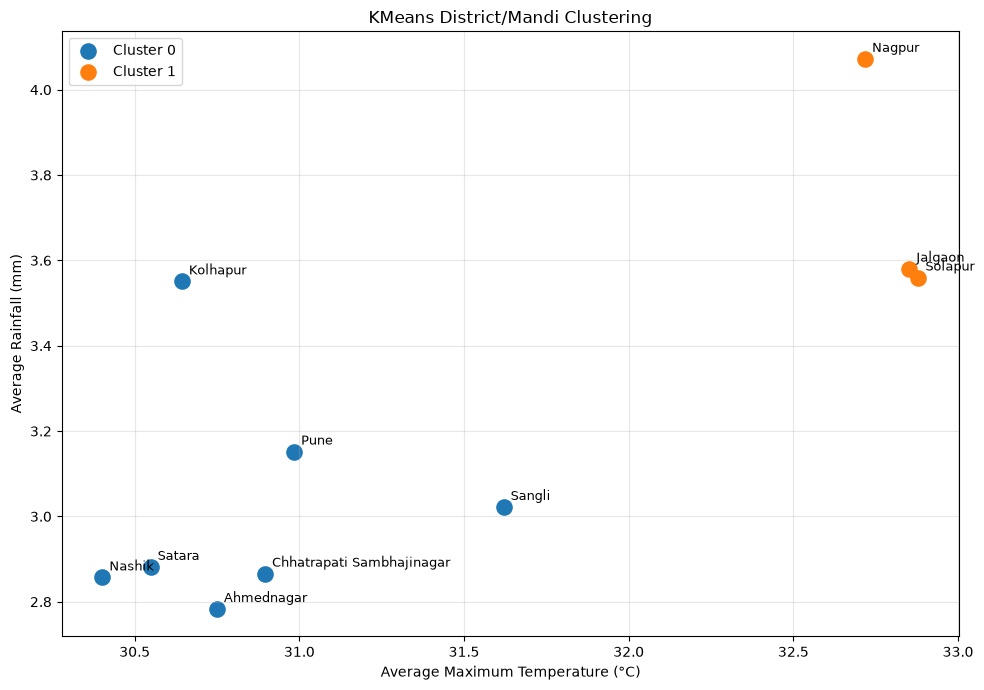


MODEL 4 — VISUALIZATION COMPLETED


In [14]:
# ==============================================================
# STEP 5 — KMEANS CLUSTER VISUALIZATION
# ==============================================================

import matplotlib.pyplot as plt


print("\n" + "=" * 70)
print("STEP 5 — KMEANS CLUSTER VISUALIZATION")
print("=" * 70)


plt.figure(figsize=(10, 7))


for cluster in sorted(
    district_features["Cluster"].unique()
):

    cluster_data = district_features[
        district_features["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["Average_Max_Temp"],
        cluster_data["Average_Rainfall"],
        s=120,
        label=f"Cluster {cluster}"
    )

    # Add district names
    for _, row in cluster_data.iterrows():

        plt.annotate(
            row["District"],
            (
                row["Average_Max_Temp"],
                row["Average_Rainfall"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )


plt.xlabel("Average Maximum Temperature (°C)")
plt.ylabel("Average Rainfall (mm)")

plt.title(
    "KMeans District/Mandi Clustering"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


print("\n" + "=" * 70)
print("MODEL 4 — VISUALIZATION COMPLETED")
print("=" * 70)

In [15]:
# ==============================================================
# STEP 6 — SAVE KMEANS RESULTS
# ==============================================================

output_file = "outputs/kmeans_mandi_clusters.csv"

district_features.to_csv(
    output_file,
    index=False
)

print("\nCluster results saved to:")
print(output_file)

OSError: Cannot save file into a non-existent directory: 'outputs'

In [16]:
import os

os.makedirs("outputs", exist_ok=True)

output_file = "outputs/kmeans_mandi_clusters.csv"

district_features.to_csv(
    output_file,
    index=False
)

print("Cluster results saved successfully!")
print(output_file)

Cluster results saved successfully!
outputs/kmeans_mandi_clusters.csv
